In [1]:
!python -m spacy download el_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 51.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
import pandas as pd
%matplotlib inline
import numpy as np
import glob
from sklearn.feature_extraction.text import CountVectorizer
from datetime import datetime

In [5]:
filepath = 'https://raw.githubusercontent.com/datajour-gr/DataJournalism/main/Bachelor%20Lessons%202023/Lesson%2010/NRC_GREEK_Translated_6_2020.csv'

In [6]:
emolex_df = pd.read_csv(filepath)
emolex_df

,word,Positive,Negative,Anger,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,Trust
0,αφεση,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ενορκη βεβαιωση,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,εχοντας,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,εχω,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,οριο,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
13166,ουρλιασμα,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13167,κροκος αυγου,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13168,νεοτερος,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13169,ζεφυρος,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
emolex_df = emolex_df.drop_duplicates(subset=['word'])
emolex_df = emolex_df.dropna()
emolex_df.reset_index(inplace = True, drop=True)

In [8]:
emolex_df.tail()

,word,Positive,Negative,Anger,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,Trust
13156,ουρλιασμα,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13157,κροκος αυγου,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13158,νεοτερος,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13159,ζεφυρος,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13160,ζουμ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
import spacy

In [10]:
nlp = spacy.load('el_core_news_sm')

In [12]:
efsyn_full_articles_df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/Notebooks εργασίας/EFSYN/efsyn_full_articles_df_cleaned.csv')
efsyn_full_articles_df

,Article No,link,title,category,date,author,summary,full_text
0,1,https://www.efsyn.gr/politiki/1402509/ntilian-...,Ντίλιαν: Συμπληρώθηκαν οι υπογραφές για κλήση ...,Βουλή,2026-06-10 14:31:00,Ολυμπία Λιάτσου,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι...","Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι..."
1,2,https://www.efsyn.gr/stiles/1402187/press-poin...,"Press Point: Νικήτα Κακλαμάνη, πάρε τα 2/5 και...",Απόψεις,2026-06-10 09:27:00,ΕΝΤΥΠΗ ΕΚΔΟΣΗΔημήτρης Κανελλόπουλος,NaN,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...
2,3,https://www.efsyn.gr/kosmos/1401911/tramp-oi-i...,Τραμπ: «Οι Ιρανοί κατέρριψαν το ελικόπτερο Apa...,Βόρεια Αμερική,2026-06-09 19:52:00,efsyn.gr,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...
3,4,https://www.efsyn.gr/politiki/1401961/epimenei...,Επιμένει ο Φλωρίδης για τις υποκλοπές: «Δεν υπ...,Παρασκήνια,2026-06-09 18:46:00,efsyn.gr,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...
4,5,https://www.efsyn.gr/politiki/1401876/ypoklope...,Υποκλοπές: Αυξάνεται η πίεση στο Μαξίμου μετά ...,Αντιπολίτευση,2026-06-09 17:10:00,efsyn.gr,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...
...,...,...,...,...,...,...,...,...
455,23,https://www.efsyn.gr/ellada/dikaiosyni/461318_...,Ο Άρειος Πάγος απαλλάσσει το πρόσωπο-κλειδί το...,Δικαιοσύνη,2025-01-29 10:34:00,efsyn.gr,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...
456,24,https://www.efsyn.gr/ellada/dikaiosyni/461186_...,Τέσσερις στο εδώλιο για το σκάνδαλο των υποκλοπών,Δικαιοσύνη,2025-01-28 12:10:00,ΕΝΤΥΠΗ ΕΚΔΟΣΗΚώστας Ζαφειρόπουλος,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...
457,25,https://www.efsyn.gr/politiki/461132_ypoklopes...,Υποκλοπές: Στο εδώλιο στις 5 Μαρτίου οι Λαβράν...,Πολιτική,2025-01-27 18:11:00,efsyn.gr,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...
458,26,https://www.efsyn.gr/politiki/paraskinia/46076...,Ύποπτη καθυστέρηση,Παρασκήνια,2025-01-24 07:38:00,ΕΝΤΥΠΗ ΕΚΔΟΣΗΚ.ΖΑΦ.,Aκόμα περιμένουμε την Εθνική να απαντήσει ποιο...,Aκόμα περιμένουμε την Εθνική να απαντήσει ποιο...


In [14]:
short_efsyn_df = pd.read_csv ('/content/gdrive/MyDrive/Colab Notebooks/Notebooks εργασίας/EFSYN/short_efsyn_df.csv')
short_efsyn_df

,date,full_text
0,2026-06-10 14:31:00,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι..."
1,2026-06-10 09:27:00,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...
2,2026-06-09 19:52:00,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...
3,2026-06-09 18:46:00,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...
4,2026-06-09 17:10:00,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...
...,...,...
454,2025-01-29 10:34:00,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...
455,2025-01-28 12:10:00,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...
456,2025-01-27 18:11:00,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...
457,2025-01-24 07:38:00,Aκόμα περιμένουμε την Εθνική να απαντήσει ποιο...


In [15]:
short_efsyn_df.dropna(subset=['full_text'], inplace=True)
short_efsyn_df.head()

,date,full_text
0,2026-06-10 14:31:00,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι..."
1,2026-06-10 09:27:00,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...
2,2026-06-09 19:52:00,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...
3,2026-06-09 18:46:00,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...
4,2026-06-09 17:10:00,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...


In [16]:
short_efsyn_df[short_efsyn_df['full_text'].isna()]

,date,full_text


In [17]:
vec = CountVectorizer(analyzer = 'word', vocabulary = emolex_df.word,
                      lowercase=False,
                      strip_accents = 'unicode',
                      stop_words= list(nlp.Defaults.stop_words),
                      ngram_range=(1, 2))

In [18]:
matrix = vec.fit_transform(short_efsyn_df['full_text'])
vocab = vec.get_feature_names_out()
wordcount_df = pd.DataFrame(matrix.toarray(), columns=vocab)
wordcount_df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['αδιακοπα', 'ακομα', 'ακομη', 'ακριβως', 'αλλα', 'αλλαχου', 'αλλες', 'αλλη', 'αλλην', 'αλλης', 'αλλιως', 'αλλιωτικα', 'αλλο', 'αλλοι', 'αλλοιως', 'αλλοιωτικα', 'αλλον', 'αλλος', 'αλλοτε', 'αλλου', 'αλλους', 'αλλων', 'αμα', 'αμεσα', 'αμεσως', 'ανα', 'αναμεσα', 'αναμεταξυ', 'ανευ', 'αντι', 'αντιπερα', 'αντις', 'ανω', 'ανωτερω', 'αξαφνα', 'απεναντι', 'απο', 'αποψε', 'αρα', 'αραγε', 'αρκετα', 'αρκετες', 'αρχικα', 'αυριο', 'αυτα', 'αυτες', 'αυτη', 'αυτην', 'αυτης', 'αυτο', 'αυτοι', 'αυτον', 'αυτος', 'αυτου', 'αυτους', 'αυτων', 'αφοτου', 'αφου', 'βεβαια', 'βεβαιοτατα', 'γιατι', 'γρηγορα', 'γυρω', 'δεινα', 'δεξια', 'δηθεν', 'δηλαδη', 'διαρκως', 'δικα', 'δικο', 'δικοι', 'δικος', 'δικου', 'δικους', 'διολου', 'διπλα', 'διχως', 'εαν', 'εαυτο', 'εαυτον', 'εαυτου', 'εαυτους', 'εαυτων', 'εγιναν', 'εγινε',

,αφεση,ενορκη βεβαιωση,εχοντας,εχω,οριο,ορμος,υδρα,αγια τραπεζα,αμην,απατσι,...,κλητηριο ενταλμα,κατειργασμενος,μαγια,κιτρινο,κιτρινιζω,ουρλιασμα,κροκος αυγου,νεοτερος,ζεφυρος,ζουμ
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
wordcount_df.shape

(447, 13161)

#Εναλλακτική για Positive/ Negative


In [20]:
positive_words_from_emolex = emolex_df[emolex_df['Positive'] == 1]['word'].tolist()
negative_words_from_emolex = emolex_df[emolex_df['Negative'] == 1]['word'].tolist()

# Filter to include only words present in wordcount_df columns
# 'vocab' is already the list of columns in wordcount_df
actual_positive_cols = [word for word in positive_words_from_emolex if word in vocab]
actual_negative_cols = [word for word in negative_words_from_emolex if word in vocab]

short_efsyn_df = short_efsyn_df.assign(
    positive=wordcount_df[actual_positive_cols].sum(axis=1),
    negative=wordcount_df[actual_negative_cols].sum(axis=1)
)
short_efsyn_df.head()

,date,full_text,positive,negative
0,2026-06-10 14:31:00,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι...",4.0,12.0
1,2026-06-10 09:27:00,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...,5.0,10.0
2,2026-06-09 19:52:00,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...,5.0,9.0
3,2026-06-09 18:46:00,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...,14.0,16.0
4,2026-06-09 17:10:00,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,54.0,53.0


#Sentiments list


In [21]:
# Φτιάξε μια λίστα με positive words
positive_words = emolex_df[emolex_df.Positive == 1]['word']

# Φτιάξε μια λίστα με negative words
negative_words = emolex_df[emolex_df.Negative == 1]['word']

# Φτιάξε μια λίστα με anger words
angry_words = emolex_df[emolex_df.Anger == 1]['word']

# Φτιάξε μια λίστα με anticipation words
anticipation_words = emolex_df[emolex_df.Anticipation == 1]['word']

# Φτιάξε μια λίστα με disgust words
disgust_words = emolex_df[emolex_df.Disgust == 1]['word']

# Φτιάξε μια λίστα με fear words
fear_words = emolex_df[emolex_df.Fear == 1]['word']

# Φτιάξε μια λίστα με joy words
joy_words = emolex_df[emolex_df.Joy == 1]['word']

# Φτιάξε μια λίστα με sadness words
sadness_words = emolex_df[emolex_df.Sadness == 1]['word']

# Φτιάξε μια λίστα με surprise words
surprise_words = emolex_df[emolex_df.Surprise == 1]['word']

# Φτιάξε μια λίστα με trust words
trust_words = emolex_df[emolex_df.Trust == 1]['word']

In [22]:
wordcount_df[positive_words].head()

,αφεση,αμην,αυγουστος,γαμηλιο ταξιδι,διευθυντρια σχολειου,δημοκρατια,επικοινωνω,εκκλησια,εν τω μεταξυ,ευαγγελιο,...,αναμφιβολως,ανυπερβατος,ανηφορικος δρομος,βελουδενιος,δικαιωσε,ζωτικης σημασιας,αδιαβροχος,καλωσορισατε,απροσδοκητα ευρημα,νεοτερος
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
wordcount_df[positive_words].sum(axis=1)

,0
0,4
1,5
2,5
3,14
4,54
...,...
442,5
443,13
444,10
445,2


In [24]:
short_efsyn_df.dropna(subset=['full_text'], inplace=True)
short_efsyn_df.reset_index(drop=True, inplace=True)

In [25]:
short_efsyn_df['anger'] = wordcount_df[angry_words].sum(axis=1)

short_efsyn_df['positive'] = wordcount_df[positive_words].sum(axis=1)

short_efsyn_df['joy'] = wordcount_df[joy_words].sum(axis=1)

short_efsyn_df['disgust'] = wordcount_df[disgust_words].sum(axis=1)

short_efsyn_df['surprise'] = wordcount_df[surprise_words].sum(axis=1)

short_efsyn_df['trust'] = wordcount_df[trust_words].sum(axis=1)

short_efsyn_df['anticipation'] = wordcount_df[anticipation_words].sum(axis=1)

short_efsyn_df['sadness'] = wordcount_df[sadness_words].sum(axis=1)

short_efsyn_df['negative'] = wordcount_df[negative_words].sum(axis=1)

short_efsyn_df['fear'] = wordcount_df[fear_words].sum(axis=1)

In [26]:
short_efsyn_df

,date,full_text,positive,negative,anger,joy,disgust,surprise,trust,anticipation,sadness,fear
0,2026-06-10 14:31:00,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι...",4,12,3,0,2,0,5,2,2,11
1,2026-06-10 09:27:00,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...,5,10,2,1,0,2,6,1,3,4
2,2026-06-09 19:52:00,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...,5,9,6,2,3,4,2,6,5,7
3,2026-06-09 18:46:00,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...,14,16,9,5,9,7,9,10,7,14
4,2026-06-09 17:10:00,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,54,53,11,8,14,13,46,15,20,45
...,...,...,...,...,...,...,...,...,...,...,...,...
442,2025-01-29 10:34:00,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...,5,10,4,1,6,2,9,3,5,7
443,2025-01-28 12:10:00,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...,13,16,4,4,5,2,10,8,8,11
444,2025-01-27 18:11:00,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...,10,12,5,2,7,3,8,6,5,10
445,2025-01-24 07:38:00,Aκόμα περιμένουμε την Εθνική να απαντήσει ποιο...,2,2,2,2,2,3,2,3,1,1


In [27]:
short_efsyn_df.isna().sum()

,0
date,0
full_text,0
positive,0
negative,0
anger,0
joy,0
disgust,0
surprise,0
trust,0
anticipation,0


In [28]:
short_efsyn_df.reset_index(inplace=True)
short_efsyn_df.set_index('date', inplace=True)
short_efsyn_df

,index,full_text,positive,negative,anger,joy,disgust,surprise,trust,anticipation,sadness,fear
date,,,,,,,,,,,,
2026-06-10 14:31:00,0,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι...",4,12,3,0,2,0,5,2,2,11
2026-06-10 09:27:00,1,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...,5,10,2,1,0,2,6,1,3,4
2026-06-09 19:52:00,2,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...,5,9,6,2,3,4,2,6,5,7
2026-06-09 18:46:00,3,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...,14,16,9,5,9,7,9,10,7,14
2026-06-09 17:10:00,4,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,54,53,11,8,14,13,46,15,20,45
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-29 10:34:00,442,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...,5,10,4,1,6,2,9,3,5,7
2025-01-28 12:10:00,443,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...,13,16,4,4,5,2,10,8,8,11
2025-01-27 18:11:00,444,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...,10,12,5,2,7,3,8,6,5,10


#Resample()

In [30]:
short_efsyn_df['year'] = pd.DatetimeIndex(short_efsyn_df.index).year.astype('Int64')
short_efsyn_df['month'] = pd.DatetimeIndex(short_efsyn_df.index).month.astype('Int64')
short_efsyn_df['day'] = pd.DatetimeIndex(short_efsyn_df.index).day.astype('Int64')
short_efsyn_df['hour'] = pd.DatetimeIndex(short_efsyn_df.index).hour.astype('Int64')

In [31]:
short_efsyn_df

,index,full_text,positive,negative,anger,joy,disgust,surprise,trust,anticipation,sadness,fear,year,month,day,hour
date,,,,,,,,,,,,,,,,
2026-06-10 14:31:00,0,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι...",4,12,3,0,2,0,5,2,2,11,2026,6,10,14
2026-06-10 09:27:00,1,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...,5,10,2,1,0,2,6,1,3,4,2026,6,10,9
2026-06-09 19:52:00,2,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...,5,9,6,2,3,4,2,6,5,7,2026,6,9,19
2026-06-09 18:46:00,3,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...,14,16,9,5,9,7,9,10,7,14,2026,6,9,18
2026-06-09 17:10:00,4,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,54,53,11,8,14,13,46,15,20,45,2026,6,9,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-29 10:34:00,442,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...,5,10,4,1,6,2,9,3,5,7,2025,1,29,10
2025-01-28 12:10:00,443,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...,13,16,4,4,5,2,10,8,8,11,2025,1,28,12
2025-01-27 18:11:00,444,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...,10,12,5,2,7,3,8,6,5,10,2025,1,27,18


<Axes: xlabel='date'>

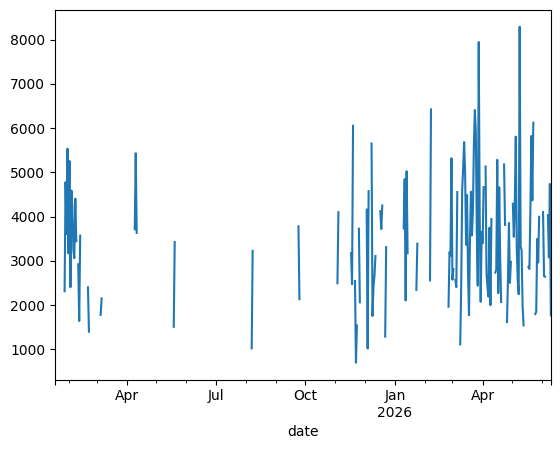

In [32]:
short_efsyn_df.index = pd.to_datetime(short_efsyn_df.index)
short_efsyn_df['full_text'].str.len().resample('D').mean().plot()

<Axes: xlabel='date'>

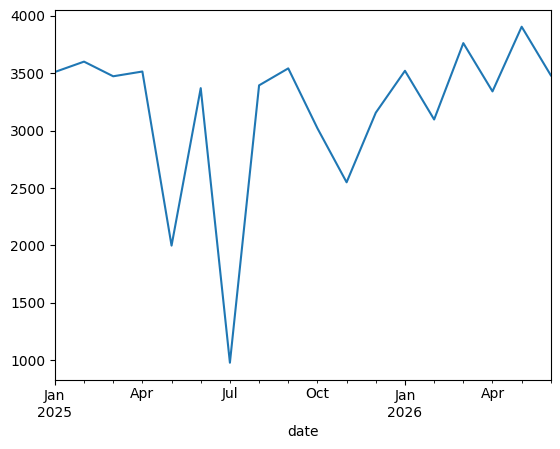

In [33]:
short_efsyn_df['full_text'].str.len().resample('ME').mean().plot()

<Axes: ylabel='date'>

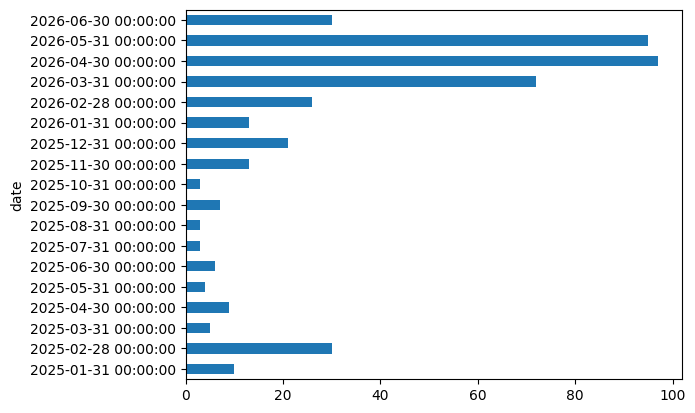

In [34]:
short_efsyn_df['full_text'].resample('ME').count().plot(kind='barh')

<Axes: xlabel='date'>

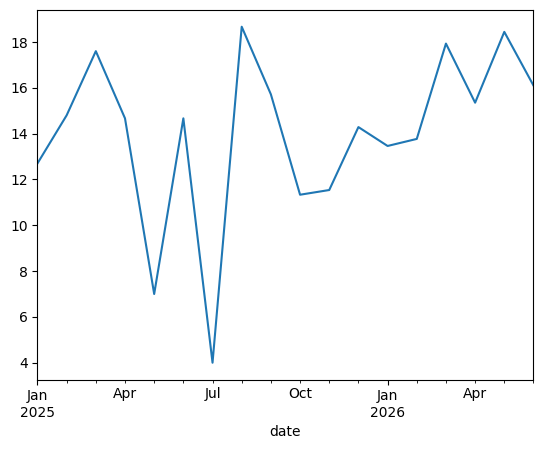

In [35]:
short_efsyn_df['positive'].resample('ME').mean().plot()

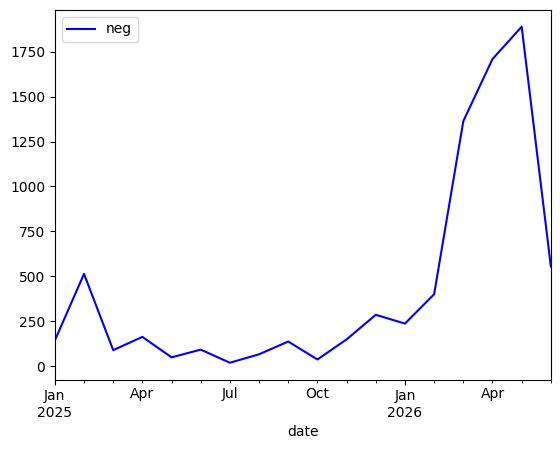

In [36]:
short_efsyn_df['negative'].resample('ME').sum().plot(color = 'b',label = 'neg').legend()

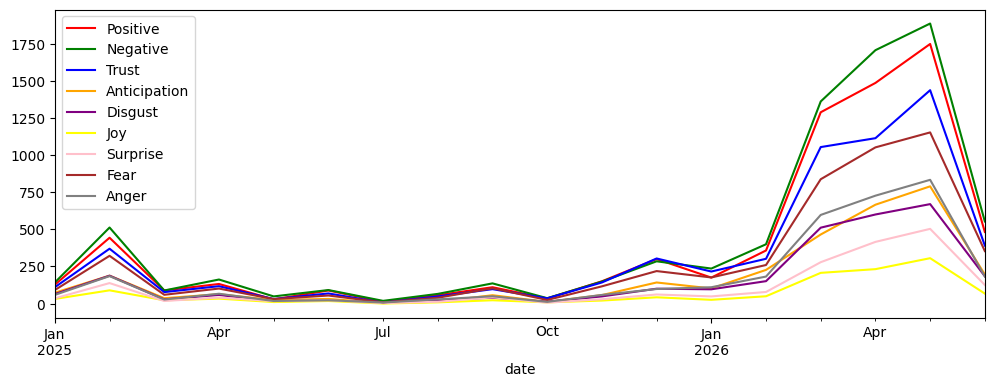

In [37]:
ax = short_efsyn_df['positive'].resample('ME').sum().plot(figsize=(12,4), color = 'red', label='Positive')
short_efsyn_df['negative'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'green', label='Negative')
ax.legend()
short_efsyn_df['trust'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'blue', label='Trust')
short_efsyn_df['anticipation'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'orange', label='Anticipation')
short_efsyn_df['disgust'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'purple', label='Disgust')
short_efsyn_df['joy'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'yellow', label='Joy')
short_efsyn_df['surprise'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'pink', label='Surprise')
short_efsyn_df['fear'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'brown', label='Fear')
short_efsyn_df['anger'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'grey', label='Anger')
ax.legend()

<Axes: xlabel='date'>

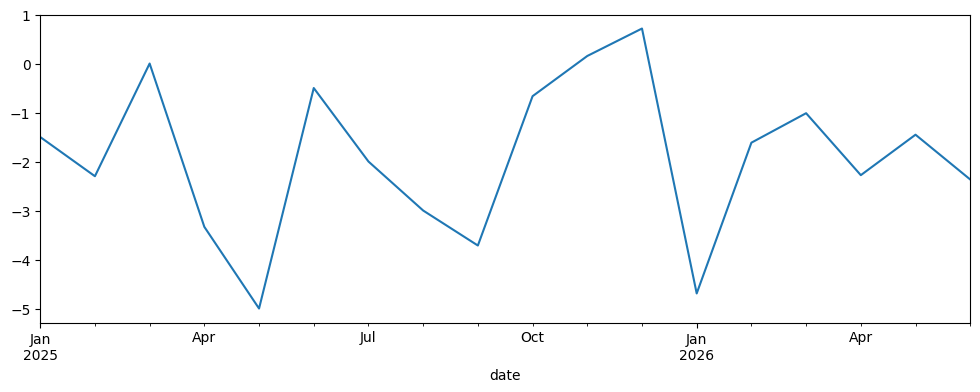

In [38]:
short_efsyn_df['pos/neg'] = short_efsyn_df['positive'] - short_efsyn_df['negative']
short_efsyn_df['pos/neg'].resample('ME').mean().plot(figsize=(12,4))

Παρατηρούμε ότι οι αρνητικές τιμές υπερτερούν των θετικών καθ'όλη την εξεταζόμενη περίοδο.

#Polarity positivity negativity

In [39]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

<Axes: xlabel='date'>

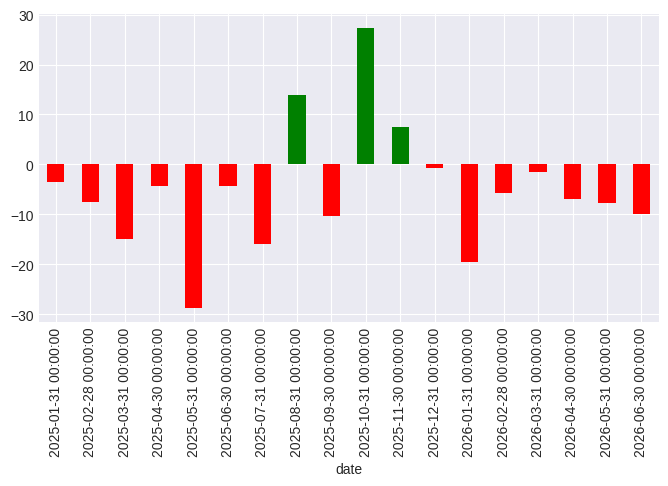

In [40]:
short_efsyn_df['(-)αρνητικότητα | θετικότητα(+)'] = short_efsyn_df.positive*100//short_efsyn_df[['positive','negative']].sum(
        axis=1) - short_efsyn_df.negative*100//short_efsyn_df[['positive','negative']].sum(axis=1)

short_efsyn_df['(-)αρνητικότητα | θετικότητα(+)'].resample('ME').mean().plot(kind='bar',
                                                                               color=(short_efsyn_df['(-)αρνητικότητα | θετικότητα(+)'].resample('ME').mean()>0
                                                                               ).map({True: 'g', False: 'r'}), figsize=(8,4))

In [41]:
short_efsyn_df[(short_efsyn_df['(-)αρνητικότητα | θετικότητα(+)'] == short_efsyn_df['(-)αρνητικότητα | θετικότητα(+)'].max()) |
                  (short_efsyn_df['(-)αρνητικότητα | θετικότητα(+)'] == short_efsyn_df['(-)αρνητικότητα | θετικότητα(+)'].min())
                  ][['index', 'positive', 'negative', '(-)αρνητικότητα | θετικότητα(+)']]

,index,positive,negative,(-)αρνητικότητα | θετικότητα(+)
date,,,,
2026-05-18 19:16:00,75,0,5,-100
2026-03-01 11:15:00,292,3,0,100
2025-11-22 13:52:00,358,3,0,100
2025-10-20 22:45:00,369,4,0,100


In [42]:
short_efsyn_df.iloc[75]['full_text']

'Η Ολομέλεια του ΣτΕ απαιτεί από την ΕΥΠ να αποστείλει εντός τριών μηνών τον φάκελο της άρσης απορρήτου του Θανάση Κουκάκη. Η Ολομέλεια τουΣυμβουλίου της Επικρατείαςδημοσίευσε σήμερα την υπ΄ αριθμ. 709/2026 απόφασή της με πρόεδρο τον Μιχάλη Πικραμένο και εισηγήτρια την σύμβουλο Επικρατείας Μαρλένα Τριπολιτσιώτη. Mε την απόφαση αυτή το ΣτΕ ζήτησε από τηνΕθνική Υπηρεσία Πληροφοριών (Ε.Υ.Π.)να στείλει τον υπηρεσιακό φάκελο τηςάρσης του απορρήτου των επικοινωνιώντου δημοσιογράφου Θανάση Κουκάκη μέσα σε ένα τρίμηνο. Με την σημερινή δημοσίευση της εν λόγω απόφασης ξεκινάει το τρίμηνο μέσα στο οποίο η Ε.Υ.Π. οφείλει να ανταποκριθεί στην απόφαση του ΣτΕ. Το κινητό τηλέφωνο του δημοσιογράφου είχε μολυνθεί με το παράνομο λογισμικό του Predator και ζήτησε από το ΣτΕ να ακυρωθεί: α) η από 1208/16.4.2025 πράξης του προέδρου της Αρχής Διασφάλισης του Απορρήτου των Επικοινωνιών (Α.Δ.Α.Ε.), με την οποία απορρίφθηκε το αίτημα του να του γνωστοποιηθούν οι λόγοι για τους οποίους είχε επιβληθεί άρση του α

Το άρθρο με τη μεγαλύτερη αρνητικότητα καταγράφηκε στις 18 Μαϊου 2026.

In [43]:
short_efsyn_df.iloc[369]['full_text']

'Όπως είπε ο Στ. Κασσελάκης επέστρεψε το εξώδικο «εκεί που ανήκει... προσάναμμα» Εξώδικο στονΣτέφανο Κασσελάκη, πρόεδρο του Κινήματος Δημοκρατίας, έστειλε οΓρηγόρης Δημητριάδης–πρώην γενικός γραμματέας του πρωθυπουργού Κυριάκου Μητσοτάκη (και ανιψιός του) και πολιτικός προϊστάμενος της ΕΥΠ–\xa0που παραιτήθηκε όταν ξέσπασε τοσκάνδαλο των υποκλοπών. Σύμφωνα με σχετικό βίντεο σε ανάρτηση του Στ. Κασσελάκη στα κοινωνικά δίκτυα, ο Γρ. Δημητριάδης «παρεξηγήθηκε… επειδή στη απάντησή μου στον Άδωνη Γεωργιάδη, του ευχήθηκα να χαίρεται τους “φραπέδες”, τους “χασάπηδες”, τους Αυγενάκηδες και τον ανιψιό που παρακολουθούσε όλους». Με αφορμή το εξώδικο, ο Στ. Κασσελάκης απευθύνει 6 ερωτήσεις στον Γρ. Δημητριάδη, όπως εάν ο ίδιος είχε την πολιτική αρμοδιότητα εποπτείας της ΕΥΠ στον χρόνο που γίνονταν οι παρακολουθήσεις. Το βίντεο ολοκληρώνεται με τον Στ. Κασσελάκη να «επιστρέφει», όπως λέει, το εξώδικο «εκεί που ανήκει… προσάναμμα», πετώντας το στη φωτιά του τζακιού του.'

In [44]:
short_efsyn_df.iloc[358]['full_text']

'Ο Σταμάτης Τρίμπαλης ανέτρεψε πλήρως την κατάθεση που είχε δώσει ενώπιον της Εξεταστικής Επιτροπής της Βουλής, λέγοντας ότι τον είχαν βάλει «μπροστινό» στην εταιρεία Krikel και του είχαν δώσει ακόμα και τις ερωτήσεις που θα του υπέβαλλαν οι βουλευτές της Ν.Δ., μαζί με τις απαντήσεις.'

In [45]:
short_efsyn_df.iloc[292]['full_text']

'Στο νέο επεισόδιο από τις «Ανάγωγες Κουβέντες», της εβδομαδιαίας σειράςpodcast της «Εφ.Συν.», το οποίο ανεβαίνει στο efsyn.gr και τις πλατφόρμες κάθε Κυριακή πρωί, οΤάσος Παππάςκαι οΔημήτρης Κανελλόπουλοςσυζητούν για τις δίκες των υποκλοπών, των Τεμπών και του… Γιάνη Βαρουφάκη για ναρκωτικά. Ηχογράφηση: EfSyn Studio © Εκφώνηση/μιξάζ/επεξεργασία/μουσική επιμέλεια: Αντώνης Παπαβομβολάκης (Music Row Studio) ® Η ΕΦΗΜΕΡΙΔΑ ΤΩΝ ΣΥΝΤΑΚΤΩΝ'

#Συναισθηματικά δίπολα

In [46]:
short_efsyn_df['joy_sadness_dipole'] = short_efsyn_df['joy'] - short_efsyn_df['sadness']
short_efsyn_df[(short_efsyn_df['joy_sadness_dipole'] == short_efsyn_df['joy_sadness_dipole'].max()) |
                  (short_efsyn_df['joy_sadness_dipole'] == short_efsyn_df['joy_sadness_dipole'].min())
                  ][['index', 'joy', 'sadness', 'joy_sadness_dipole']]


,index,joy,sadness,joy_sadness_dipole
date,,,,
2026-05-18 19:58:00,74,9,2,7
2026-05-05 21:45:00,108,7,38,-31


In [47]:
short_efsyn_df['trust_disgust_dipole'] = short_efsyn_df['trust'] - short_efsyn_df['disgust']
short_efsyn_df[(short_efsyn_df['trust_disgust_dipole'] == short_efsyn_df['trust_disgust_dipole'].max()) |
                  (short_efsyn_df['trust_disgust_dipole'] == short_efsyn_df['trust_disgust_dipole'].min())
                  ][['index', 'trust', 'disgust', 'trust_disgust_dipole']]


,index,trust,disgust,trust_disgust_dipole
date,,,,
2026-05-05 08:26:00,114,13,21,-8
2026-03-28 14:32:00,232,64,23,41


In [48]:
short_efsyn_df['fear_anger_dipole'] = short_efsyn_df['fear'] - short_efsyn_df['anger']
short_efsyn_df[(short_efsyn_df['fear_anger_dipole'] == short_efsyn_df['fear_anger_dipole'].max()) |
                  (short_efsyn_df['fear_anger_dipole'] == short_efsyn_df['fear_anger_dipole'].min())
                  ][['index', 'fear', 'anger', 'fear_anger_dipole']]



,index,fear,anger,fear_anger_dipole
date,,,,
2026-06-09 17:10:00,4,45,11,34
2026-03-20 09:35:00,255,20,34,-14


In [49]:
short_efsyn_df.iloc[255]['full_text']

'Αναφορές σε «εθνική πυξίδα», κριτική για τις ελληνοαμερικανικές σχέσεις και επίθεση στην κυβέρνηση για υποκλοπές και διαφθορά, με ταυτόχρονο άνοιγμα στη συζήτηση για ένα νέο πολιτικό σχήμα Ο Αλέξης Τσίπρας, με αφορμή την παρουσίαση του βιβλίου του «Ιθάκη» στην Αλεξανδρούπολη, έδωσε μια ομιλία με έντονο πολιτικό περιεχόμενο, που ξεπέρασε τα όρια της εκδήλωσης και λειτούργησε ως συνολική παρέμβαση για την εξωτερική πολιτική, την εσωτερική κατάσταση της χώρας και τις επόμενες πολιτικές εξελίξεις. Από την αρχή της τοποθέτησής του, ανέδειξε τη γεωπολιτική σημασία της περιοχής, τονίζοντας ότι η Αλεξανδρούπολη και συνολικά η Θράκη δεν αποτελούν περιφερειακό χώρο, αλλά έναν κρίσιμο κόμβο με αυξανόμενο ρόλο στις διεθνείς εξελίξεις. Υπογράμμισε ότι η Ελλάδα πρέπει να αξιοποιεί αυτή τη θέση με στρατηγικό τρόπο, χωρίς να λειτουργεί ως δεδομένος και προβλέψιμος σύμμαχος. Κεντρικό στοιχείο της ομιλίας του αποτέλεσε η έννοια της «εθνικής πυξίδας», την οποία παρουσίασε ως αναγκαία προϋπόθεση για την 

In [50]:
short_efsyn_df['surprise_anticipation_dipole'] = short_efsyn_df['surprise'] - short_efsyn_df['anticipation']
short_efsyn_df[(short_efsyn_df['surprise_anticipation_dipole'] == short_efsyn_df['surprise_anticipation_dipole'].max()) |
                  (short_efsyn_df['surprise_anticipation_dipole'] == short_efsyn_df['surprise_anticipation_dipole'].min())
                  ][['index', 'surprise', 'anticipation', 'surprise_anticipation_dipole']]

,index,surprise,anticipation,surprise_anticipation_dipole
date,,,,
2026-05-06 07:25:00,107,17,10,7
2026-05-05 08:26:00,114,6,24,-18


In [51]:
short_efsyn_df.iloc[114]['full_text']

'Βουλή: Προανακριτική κατά δύο υπουργών για το σκάνδαλο των παράνομων επιδοτήσεων ζητεί η αντιπολίτευση, αλλά και να ανοίξει ξανά ο φάκελος των παρακολουθήσεων μέσω Εξεταστικής. Μια ακόμα δύσκολη εβδομάδα άρχισε χθες για την κυβέρνηση, μετά το νέο διπλό σφυροκόπημα της αντιπολίτευσης, στον απόηχο των δύο πολύκροτων σκανδάλων. 1.Υποκλοπές:το ΠΑΣΟΚ κατέθεσε πρόταση για σύσταση Εξεταστικής Επιτροπής για να ανοίξει ξανά ο φάκελος των υποκλοπών με αιχμή τα νέα στοιχεία που έχουν έρθει στο φως της δημοσιότητας. 2.ΟΠΕΚΕΠΕ:ΣΥΡΙΖΑ και Νέα Αριστερά προχώρησαν από κοινού σε πρόταση για τη σύσταση Προανακριτικής κατά του Σπήλιου Λιβανού και της Φωτεινής Αραμπατζή. Είναι η δεύτερη πρόταση που κατατίθεται στη Βουλή για σύσταση Προανακριτικής κατά των γαλάζιων πρώην υπουργών με βάση τη νέα δικογραφία της Ευρωπαϊκής Εισαγγελίας για την υπόθεση του ΟΠΕΚΕΠΕ, καθώς έχει προηγηθεί εκείνη του ΠΑΣΟΚ την περασμένη Πέμπτη. Με την πρόταση για Εξεταστική, που είχε ήδη προαναγγείλει ο Νίκος Ανδρουλάκης, η κοινοβ

#Κείμενα με το μεγαλύτερο σκορ κάθε συναισθήματος

In [52]:
# Install wordcloud library if not already installed
!pip install wordcloud matplotlib

In [53]:
# Find the 2 angriest texts, including their index and full text
print("\nTop 5 angriest texts:")
display(short_efsyn_df.sort_values(by='anger', ascending=False).head(5)[['index', 'full_text', 'anger']])


Top 5 angriest texts:


,index,full_text,anger
date,,,
2026-04-16 20:00:00,180,«Να μην κρατά η Ευρωπαϊκή Εισαγγελία όμηρους 1...,37
2026-02-26 21:30:00,302,Η ιστορική δικαστική απόφαση για το σκάνδαλο τ...,37
2026-04-04 08:45:00,214,«Με το ΠΑΣΟΚ να προτιμά την ακυβερνησία από το...,35
2026-03-20 09:35:00,255,"Αναφορές σε «εθνική πυξίδα», κριτική για τις ε...",34
2026-05-21 19:35:00,52,"Στη συζήτηση γύρω από τις υποκλοπές, ο πρόεδρο...",28


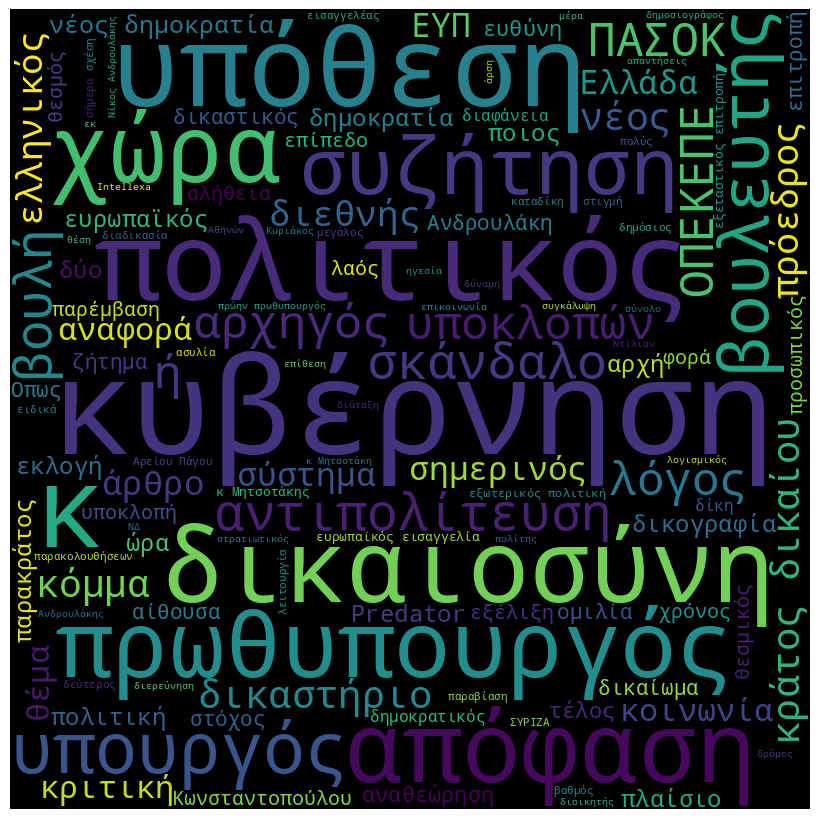

In [56]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os # Added to get current working directory

# Get the full_text of the top 5 angriest articles
angriest_texts = short_efsyn_df.sort_values(by='anger', ascending=False).head(5)['full_text']

# Perform lemmatization on the angriest texts, excluding all verbs
lemmatized_angriest_texts = []
for text in angriest_texts:
    doc = nlp(text)
    # Exclude punctuation, spaces, and all verbs
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space and token.pos_ != 'VERB']
    lemmatized_angriest_texts.append(' '.join(lemmas))

# Concatenate all lemmatized texts into a single string
all_angriest_text = ' '.join(lemmatized_angriest_texts)

# Generate the word cloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = nlp.Defaults.stop_words,
                min_font_size = 10).generate(all_angriest_text)

# Display the word cloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.savefig('Efsyn_angriest_words.png')
plt.show()

print(f"Το αρχείο 'Efsyn_angriest_words.png' αποθηκεύτηκε στη διαδρομή: {os.getcwd()}/Efsyn_angriest_words.png") # Added to show save path

In [57]:
print("\nTop 5 fearest texts:")
display(short_efsyn_df.sort_values(by='fear', ascending=False).head(5)[['index', 'full_text', 'fear']])


Top 5 fearest texts:


,index,full_text,fear
date,,,
2026-04-04 08:45:00,214,«Με το ΠΑΣΟΚ να προτιμά την ακυβερνησία από το...,54
2026-02-26 21:30:00,302,Η ιστορική δικαστική απόφαση για το σκάνδαλο τ...,49
2026-06-09 17:10:00,4,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,45
2026-04-28 06:41:00,154,Ο κ. Τζαβέλλας είχε ήδη από το 2020 ενεργή εμπ...,41
2026-04-16 20:00:00,180,«Να μην κρατά η Ευρωπαϊκή Εισαγγελία όμηρους 1...,38


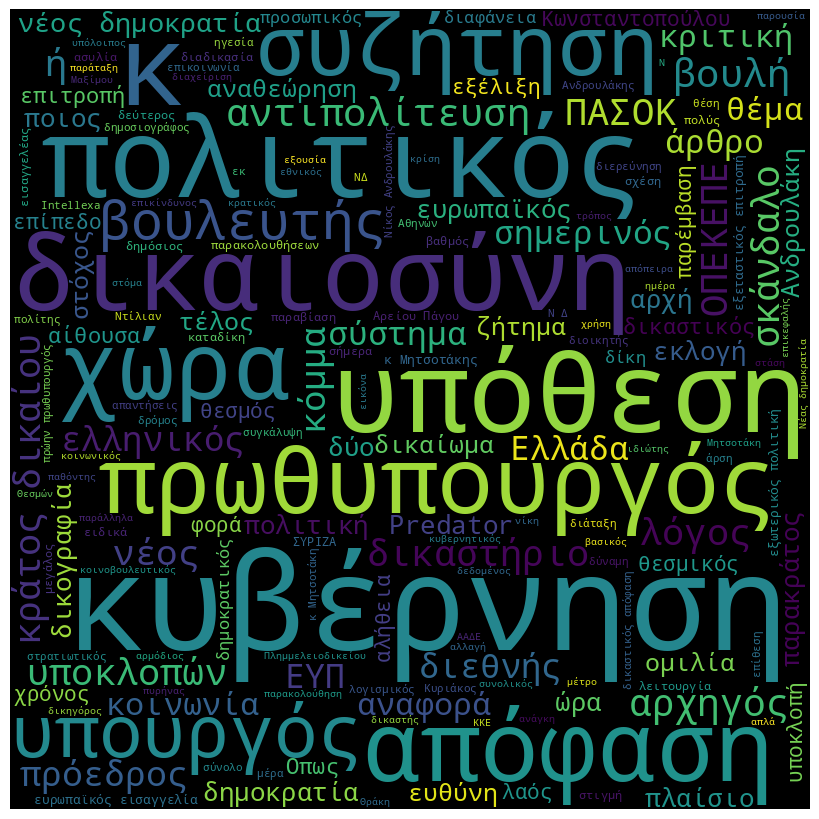

In [61]:
# Get the full_text of the top 5 angriest articles
fearest_texts = short_efsyn_df.sort_values(by='fear', ascending=False).head(5)['full_text']

# Perform lemmatization on the angriest texts, excluding all verbs
lemmatized_fearest_texts = []
for text in fearest_texts:
    doc = nlp(text)
    # Exclude punctuation, spaces, and all verbs
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space and token.pos_ != 'VERB']
    lemmatized_angriest_texts.append(' '.join(lemmas))

# Concatenate all lemmatized texts into a single string
all_fearest_text = ' '.join(lemmatized_fearest_texts)

# Generate the word cloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = nlp.Defaults.stop_words,
                min_font_size = 10).generate(all_angriest_text)

# Display the word cloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.savefig('Efsyn_fearest_words.png')
plt.show()

In [62]:
print("\nTop 5 textt with disgust:")
display(short_efsyn_df.sort_values(by='disgust', ascending=False).head(5)[['index', 'full_text', 'disgust']])


Top 5 textt with disgust:


,index,full_text,disgust
date,,,
2026-04-04 08:45:00,214,«Με το ΠΑΣΟΚ να προτιμά την ακυβερνησία από το...,35
2026-04-28 12:54:00,148,Σφοδρή επίθεση εξαπέλυσε ο κυβερνητικός εκπρόσ...,29
2026-04-16 20:00:00,180,«Να μην κρατά η Ευρωπαϊκή Εισαγγελία όμηρους 1...,29
2026-02-26 21:30:00,302,Η ιστορική δικαστική απόφαση για το σκάνδαλο τ...,27
2026-03-13 14:51:00,271,Η παραδοχή του Ταλ Ντίλιαν της Intellexa άναψε...,27


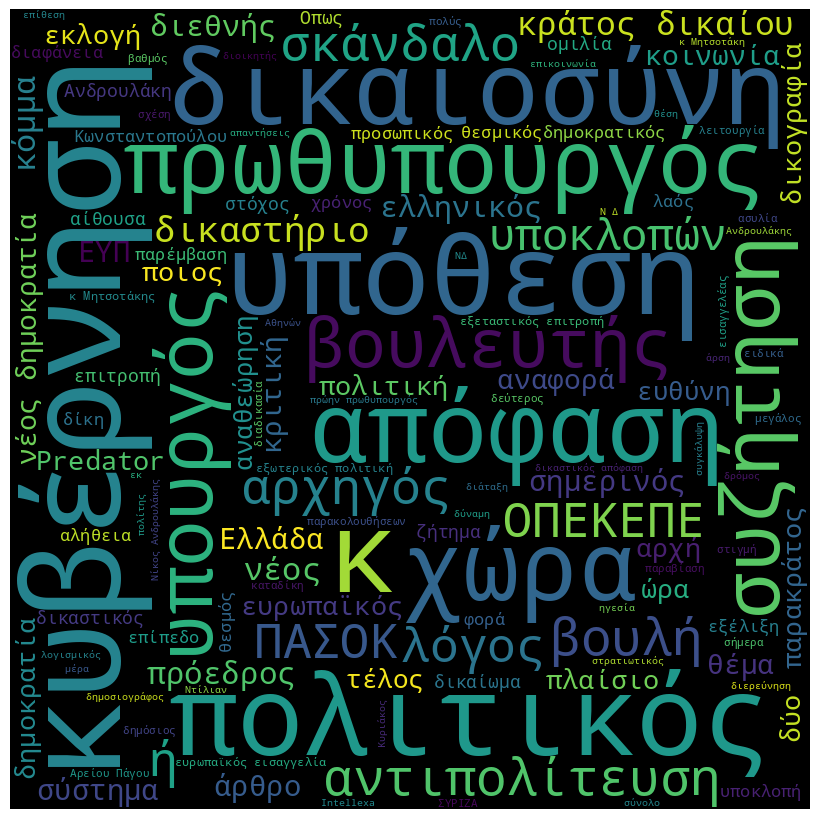

In [63]:
# Get the full_text of the top 5 angriest articles
disgust_texts = short_efsyn_df.sort_values(by='disgust', ascending=False).head(5)['full_text']

# Perform lemmatization on the angriest texts, excluding all verbs
lemmatized_disgust_texts = []
for text in disgust_texts:
    doc = nlp(text)
    # Exclude punctuation, spaces, and all verbs
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space and token.pos_ != 'VERB']
    lemmatized_disgust_texts.append(' '.join(lemmas))

# Concatenate all lemmatized texts into a single string
all_disgust_text = ' '.join(lemmatized_disgust_texts)

# Generate the word cloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = nlp.Defaults.stop_words,
                min_font_size = 10).generate(all_angriest_text)

# Display the word cloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.savefig('Efsyn_disgust_words.png')
plt.show()

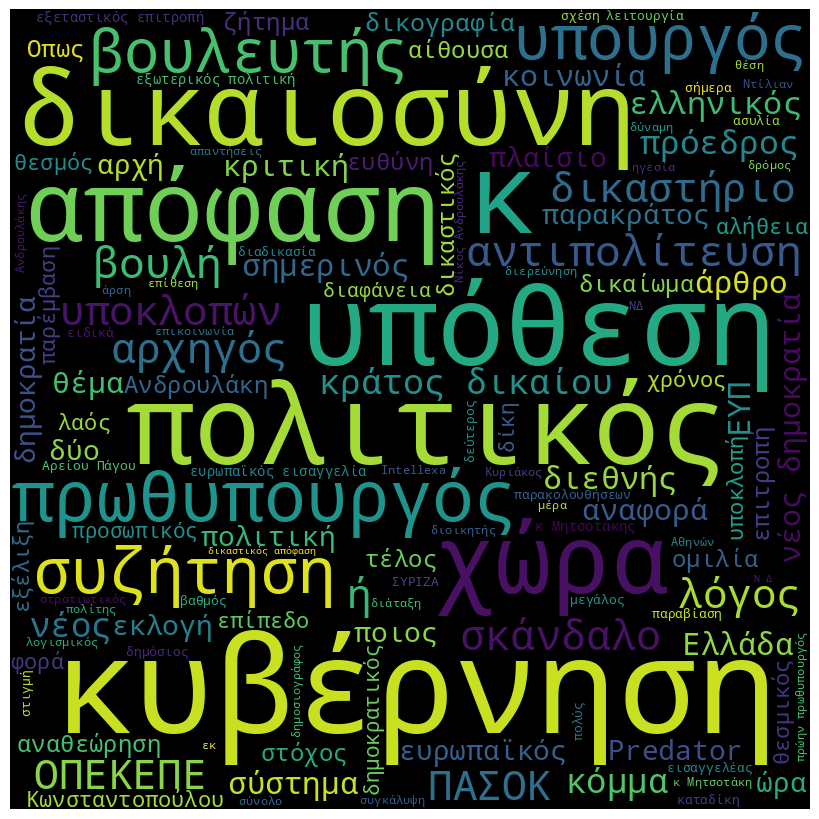

In [64]:
# Get the full_text of the top 5 angriest articles
surprise_texts = short_efsyn_df.sort_values(by='surprise', ascending=False).head(5)['full_text']

# Perform lemmatization on the angriest texts, excluding all verbs
lemmatized_surprise_texts = []
for text in surprise_texts:
    doc = nlp(text)
    # Exclude punctuation, spaces, and all verbs
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space and token.pos_ != 'VERB']
    lemmatized_angriest_texts.append(' '.join(lemmas))

# Concatenate all lemmatized texts into a single string
all_surprise_text = ' '.join(lemmatized_fearest_texts)

# Generate the word cloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = nlp.Defaults.stop_words,
                min_font_size = 10).generate(all_angriest_text)

# Display the word cloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.savefig('Efsyn_surprise_words.png')
plt.show()